In [3]:
import numpy as np
import pandas as pd

In [17]:
df = pd.read_csv("https://raw.githubusercontent.com/kolomna-trams/open-data/refs/heads/main/crowd/crowd_raw.csv")
def convert_time_to_minutes(time_str):
    hours, minutes = time_str.split(':')
    total_minutes = int(hours) * 60 + int(minutes)
    return total_minutes

df['time'] = df['time'].apply(convert_time_to_minutes)
df = df.fillna(120)
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear
df['day_mon'] = df['date'].dt.strftime('%d.%m')

df.drop(columns=['date'], inplace=True)
df['passengers_before'] = df['passengers'] - df['inbound'] + df['outbound']
df.drop(["thunder"], axis=1, inplace=True)
df.head()

,travel_id,tram_no,weekday,day_of_week,precipitation,wind,temperature,route_length,stop,time,...,outbound,passengers,wheelchair,seating,standing,month,day,day_of_year,day_mon,passengers_before
0,1,5,WDS,THU,0,0,18,4390,0300aF,534,...,0,36,1,33,94,9,26,270,26.09,0
1,1,5,WDS,THU,0,0,18,4390,0301aF,536,...,0,41,1,33,94,9,26,270,26.09,36
2,1,5,WDS,THU,0,0,18,4390,0302aF,538,...,2,39,1,33,94,9,26,270,26.09,41
3,1,5,WDS,THU,0,0,18,4390,0303aF,539,...,1,38,1,33,94,9,26,270,26.09,39
4,1,5,WDS,THU,0,0,18,4390,0200aB,542,...,13,26,1,33,94,9,26,270,26.09,38


Матрица корреляции

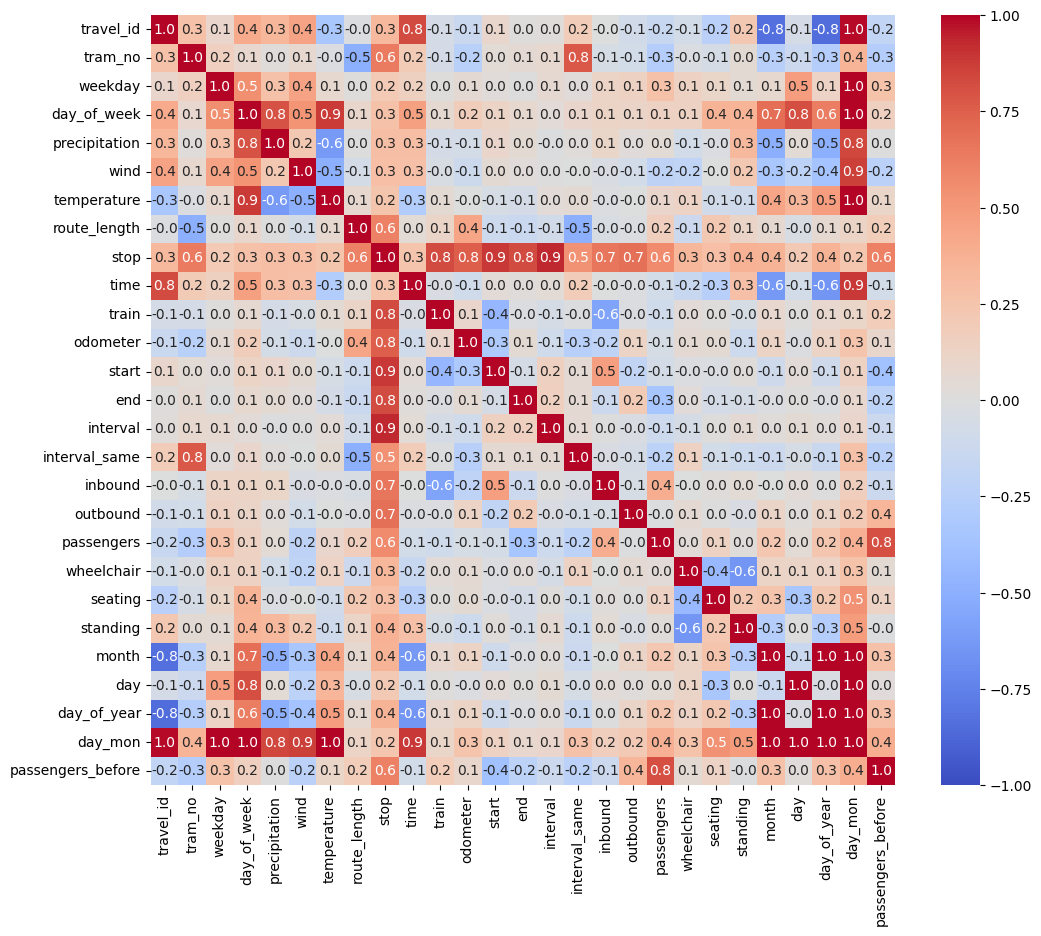

In [ ]:
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

def correlation_ratio(categories, values):
    categories = pd.Series(categories)
    values = pd.Series(values)
    cat_means = values.groupby(categories).mean()
    ss_between = sum(categories.value_counts() * (cat_means - values.mean())**2)
    ss_total = ((values - values.mean())**2).sum()
    return np.sqrt(ss_between / ss_total)

def mixed_corr_matrix(df):
    cols = df.columns
    n = len(cols)
    matrix = pd.DataFrame(np.ones((n, n)), index=cols, columns=cols)
    
    for i in range(n):
        for j in range(i + 1, n):
            col1, col2 = cols[i], cols[j]
            t1 = df[col1].dtype
            t2 = df[col2].dtype
            is_num1 = pd.api.types.is_numeric_dtype(t1)
            is_num2 = pd.api.types.is_numeric_dtype(t2)
            
            if is_num1 and is_num2:
                val = df[col1].corr(df[col2])
            elif not is_num1 and not is_num2:
                val = cramers_v(df[col1], df[col2])
            elif is_num1 and not is_num2:
                val = correlation_ratio(df[col2], df[col1])
            else:
                val = correlation_ratio(df[col1], df[col2])
            
            matrix.iloc[i, j] = val
            matrix.iloc[j, i] = val
    return matrix

corr_matrix = mixed_corr_matrix(df)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0)
plt.show()